In [1]:
import sys
sys.path.append("..")

from src.clonality import run_clonality_analysis
from src.dataset_loader import load_dataset

import scanpy as sc
import matplotlib
from matplotlib import rcParams

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, dpi_save=300, color_map='Reds', facecolor='white')
matplotlib.rcParams.update({'figure.figsize': (6, 6)})


# adata_peri = load_dataset("perigas_bgi")
# adata_perigas_endo = load_dataset("perigas_endo")
# adata_hypo = load_dataset("embryotree_hypo")
# adata_embryo = load_dataset("embryotree")

In [2]:
%config InlineBackend.figure_format = 'retina'

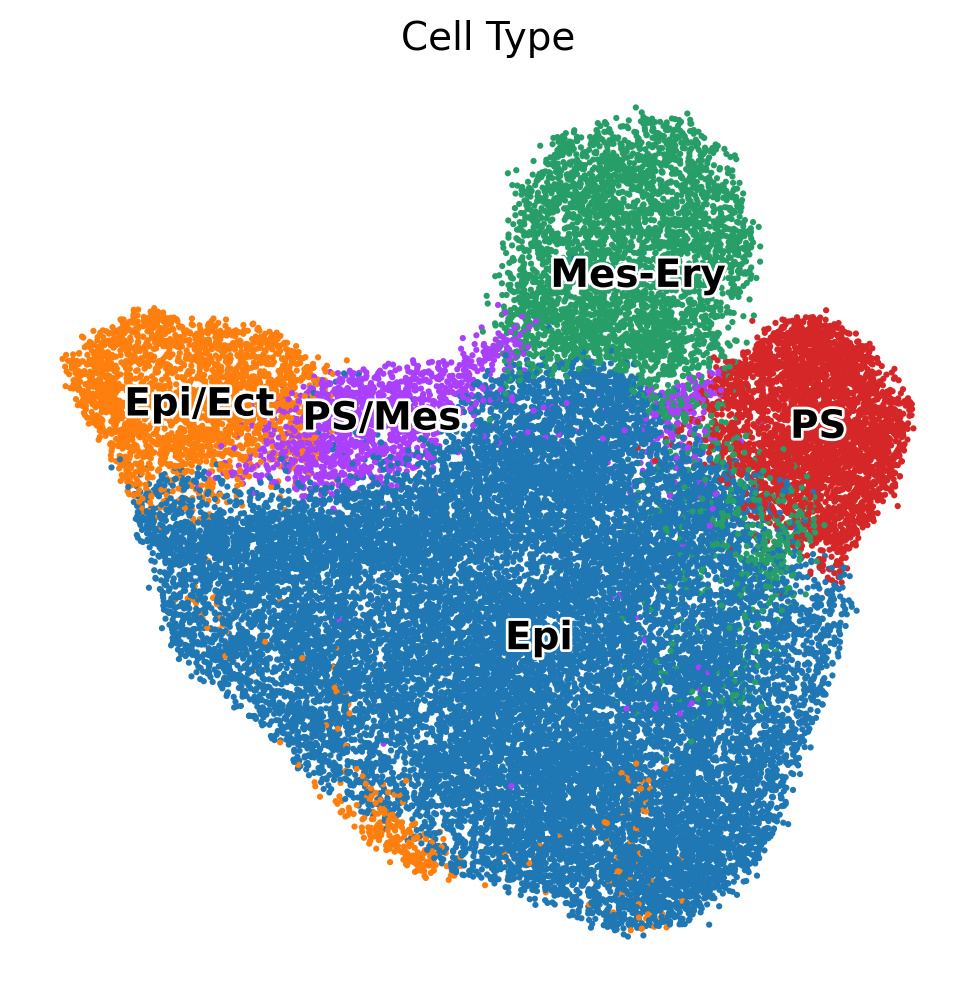

In [22]:
sc.pl.umap(adata, color=['CellType_man'], frameon=False, legend_loc='on data', 
           legend_fontsize=14, legend_fontoutline=2, title='Cell Type', 
           size=20)

[<Axes: title={'center': 'POU5F1'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'SOX17'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'AFP'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'APOA1'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'CXCR4'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'CDX2'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'PDGFRA'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'HAND1'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'COL1A1'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'GYPB'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'HBZ'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'HBE1'}, xlabel='UMAP1', ylabel='UMAP2'>]

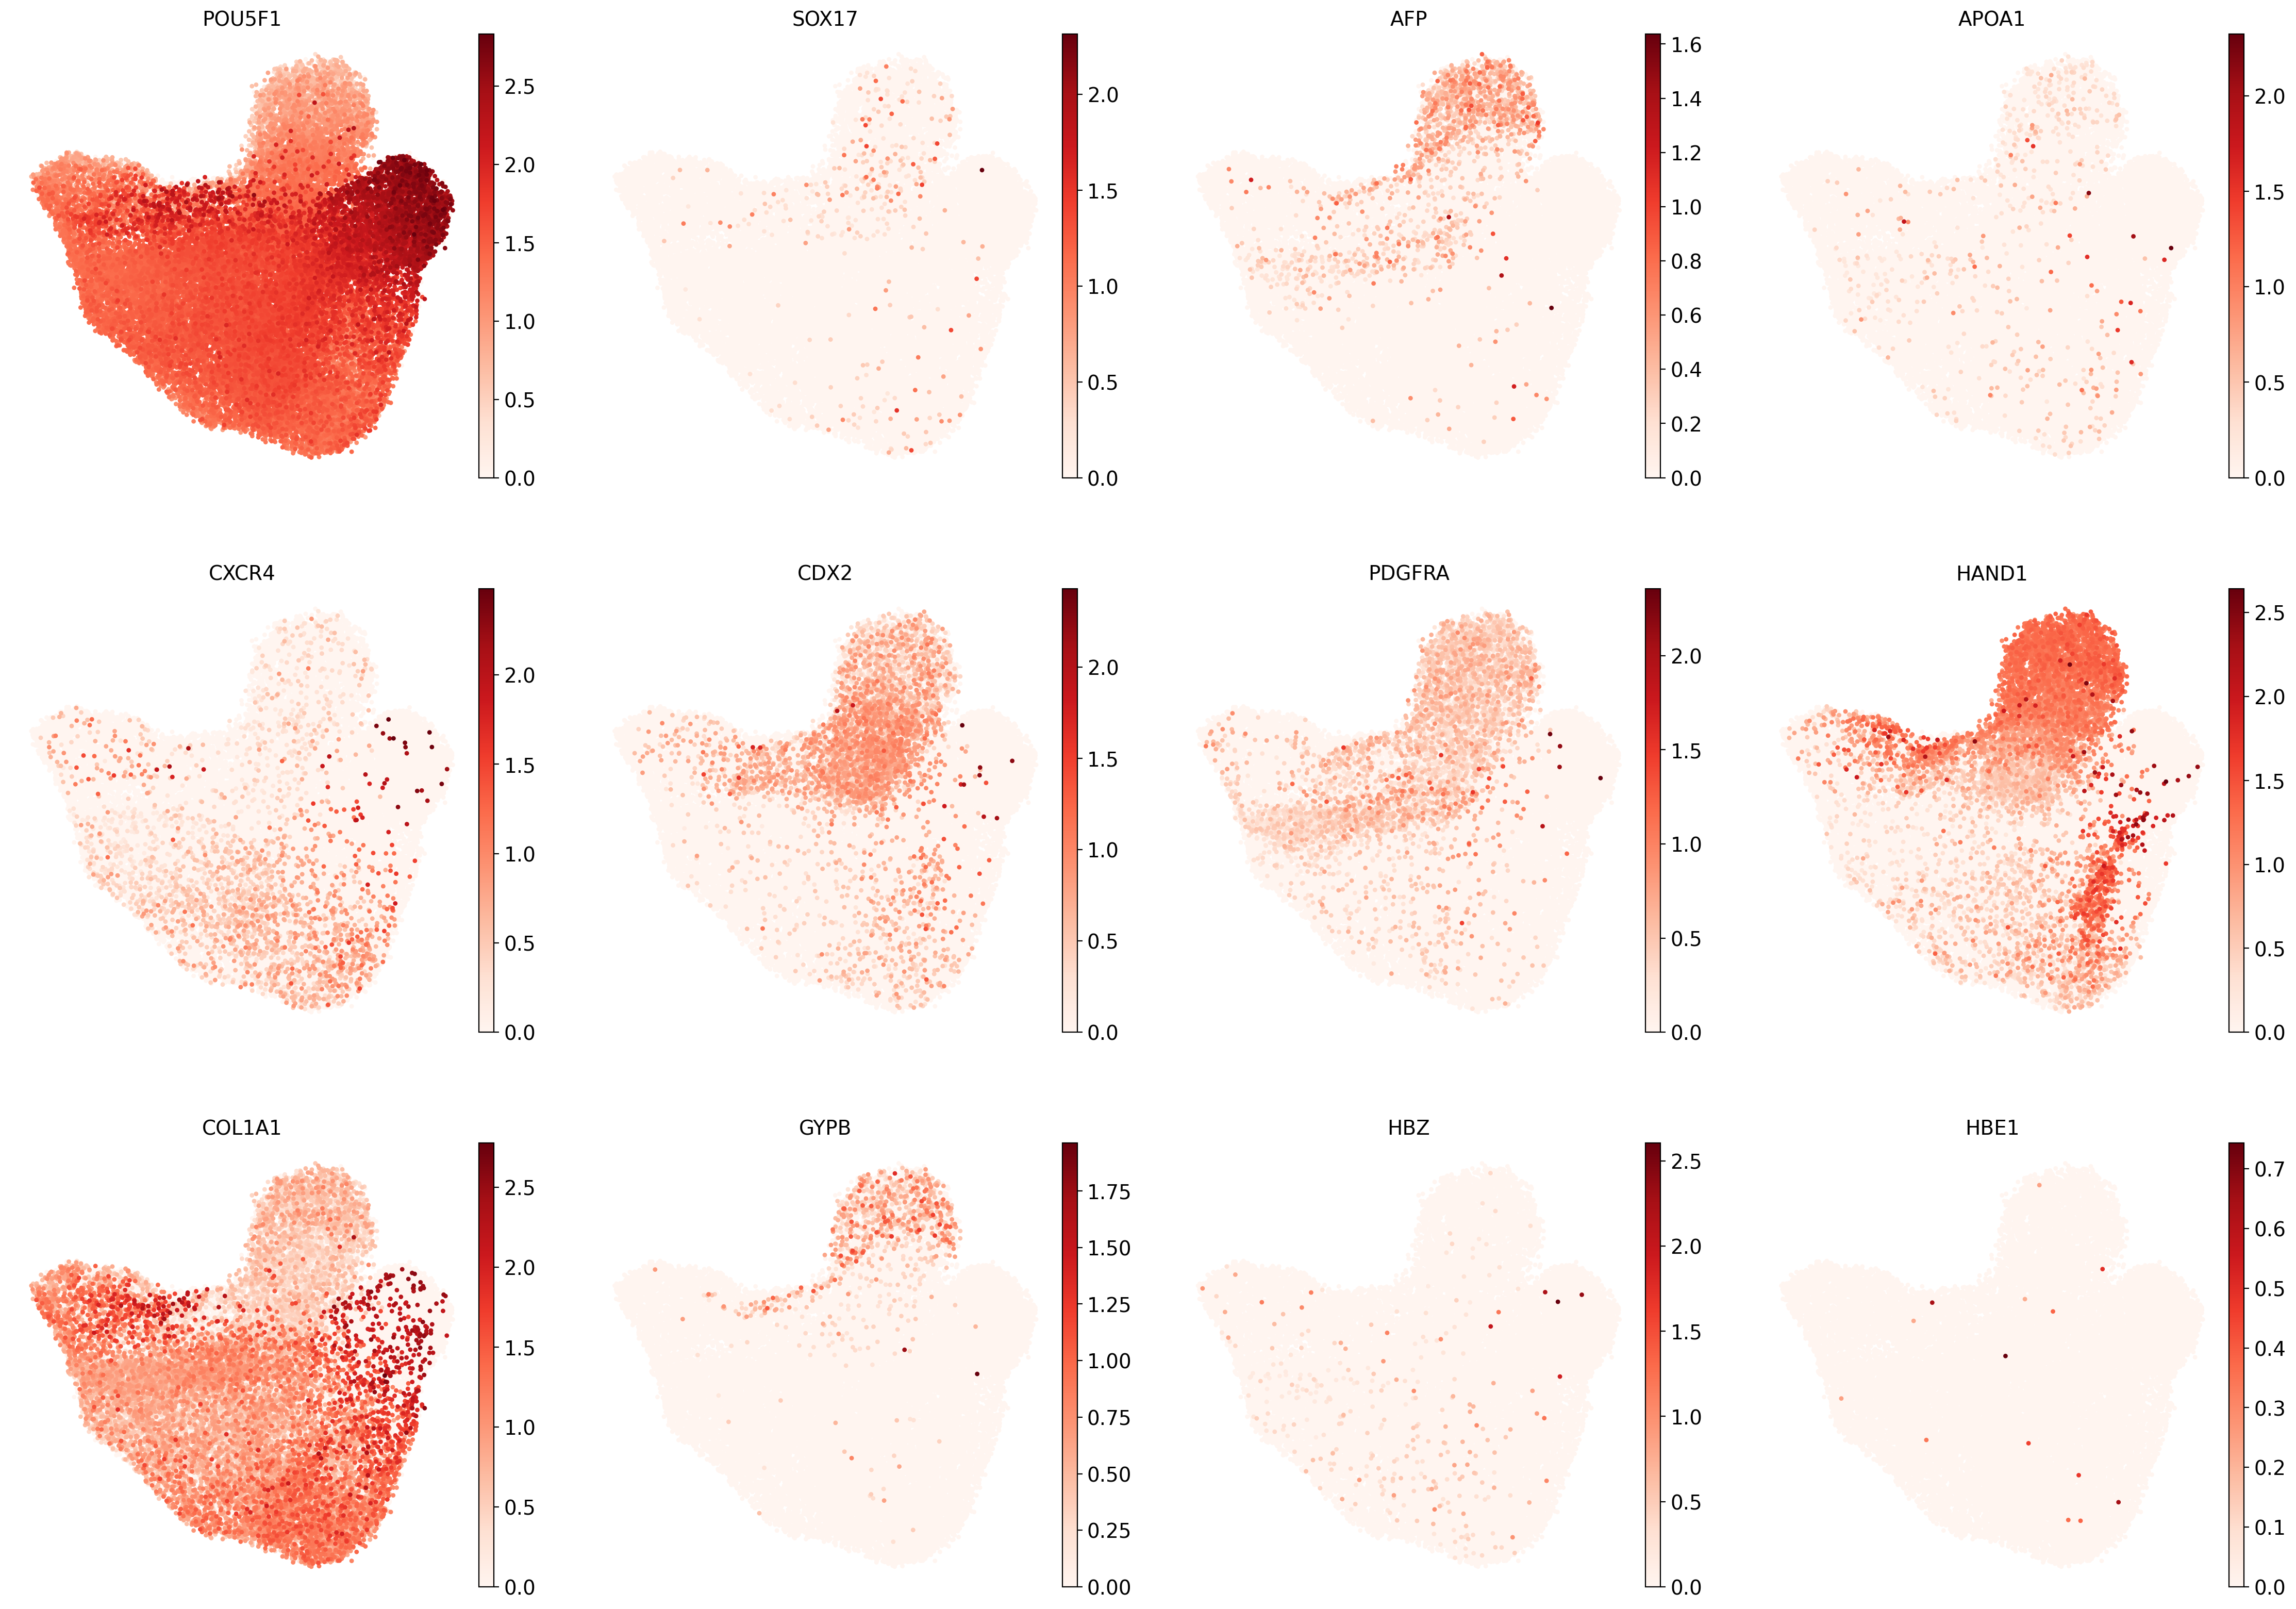

In [52]:
sc.pl.umap(adata, color=['POU5F1', 'SOX17', 'AFP', 'APOA1', 'CXCR4',
                             'CDX2', 'PDGFRA', 'HAND1', 'COL1A1', 
                         'GYPB', 'HBZ', 'HBE1'], 
           frameon=False, size=40, show=False)

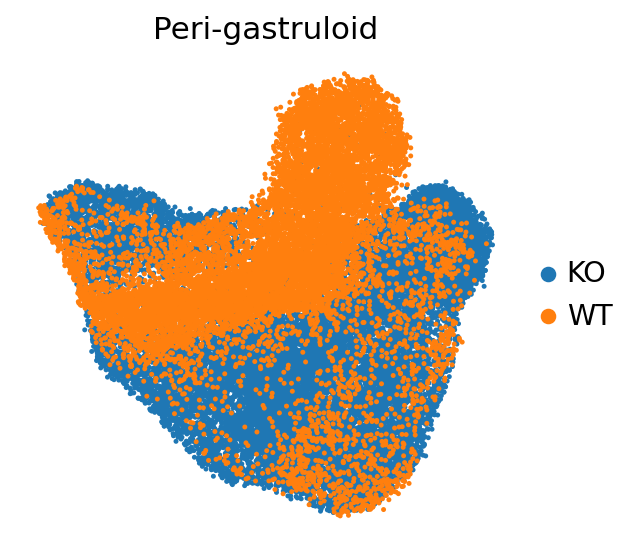

In [30]:
sc.pl.umap(adata, color='group', title='Peri-gastruloid', 
          frameon=False, size=20)

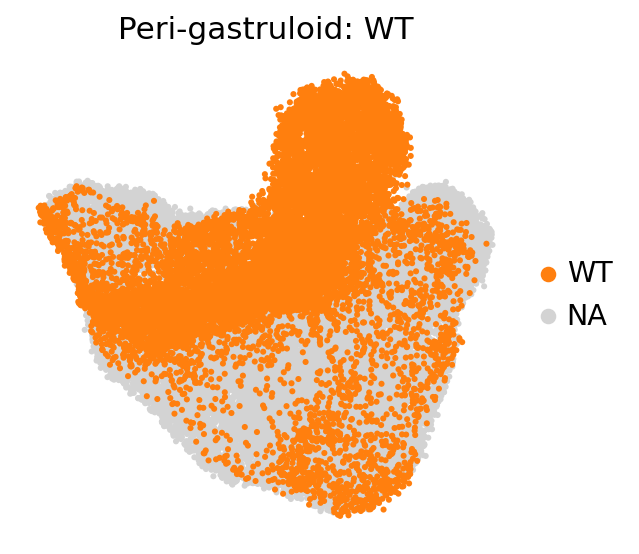

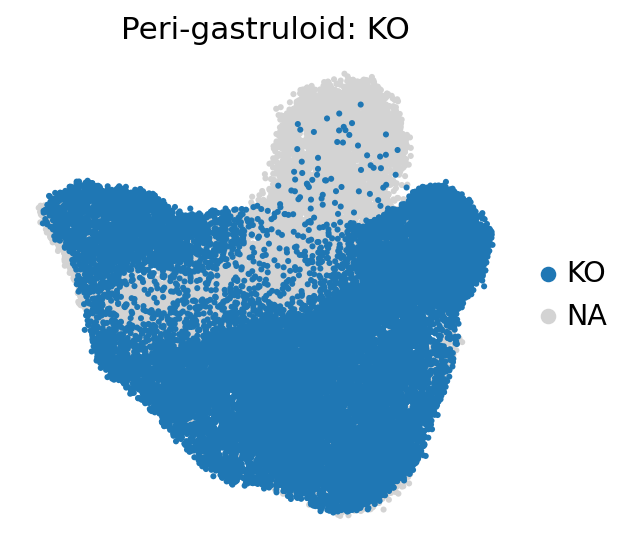

In [32]:
sc.pl.umap(adata, 
           color='group', 
           groups=['WT'], 
           title='Peri-gastruloid: WT',
           frameon=False, 
           size=30,
           na_color='lightgray') 

sc.pl.umap(adata, 
           color='group', 
           groups=['KO'], 
           title='Peri-gastruloid: KO',
           frameon=False, 
           size=30,
           na_color='lightgray')

In [ ]:
adata_d8 = adata[adata.obs['sample'].isin(['wt_d8', 'ko_d8'])]

/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


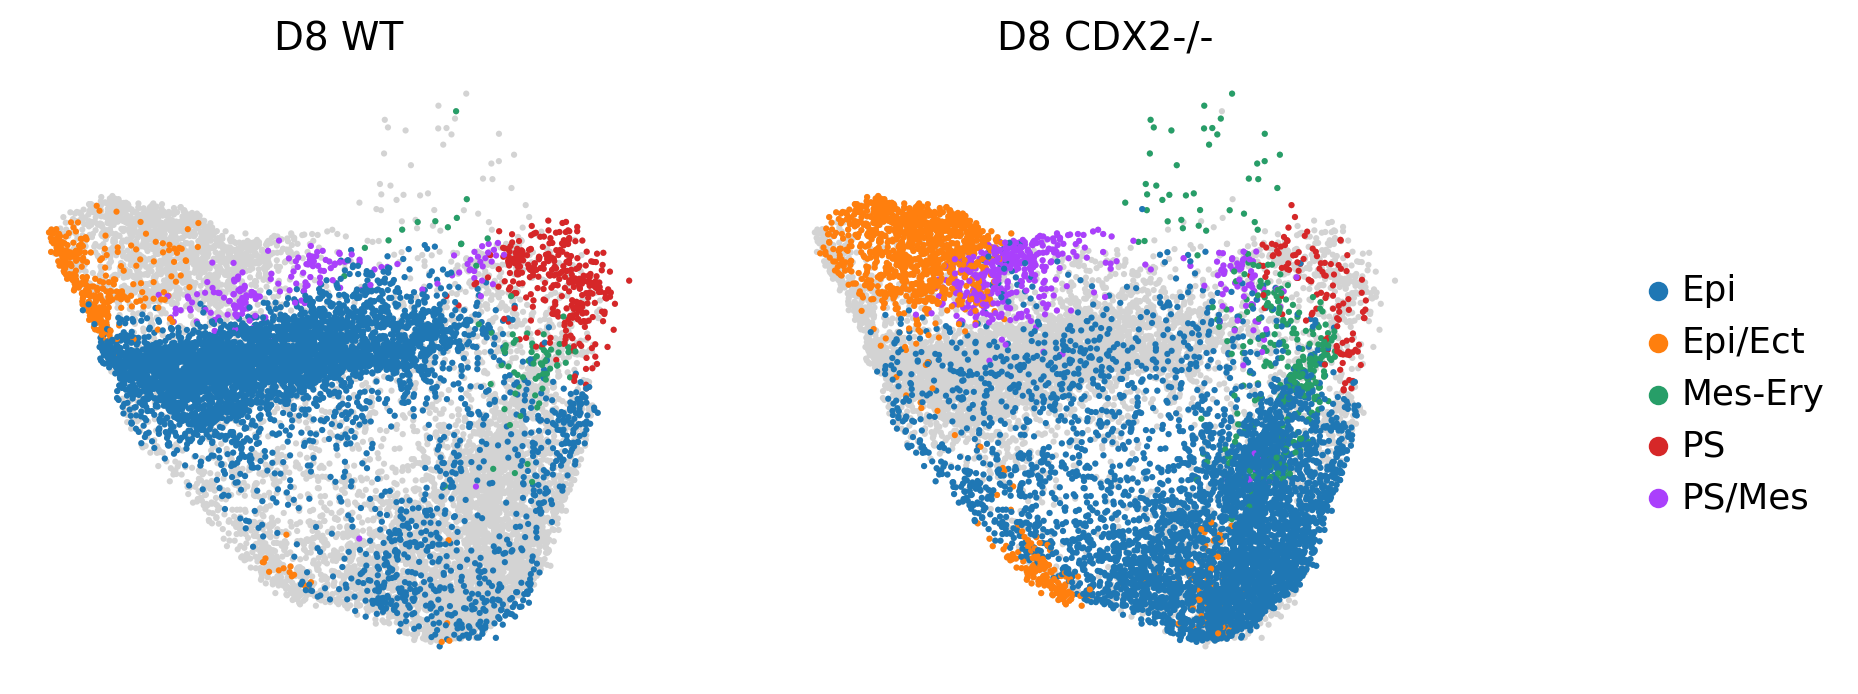

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# plot
num = list(np.arange(0, 2, 1))
sample_order = ['WT', 'KO']
sample_dict = dict(zip(num, sample_order))

fig, axs = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={'hspace': 0.3, 'wspace': 0.2})
axs = axs.flatten()

legend_handles = []
legend_labels = []

display_titles = ['D8 WT', 'D8 CDX2-/-']

for i in sample_dict:
    sc.pl.umap(adata_d8, size=20, show=False, ax=axs[i], return_fig=fig)
    sc.pl.umap(adata_d8[adata_d8.obs['group'] == sample_order[i]], color='CellType_man', size=20, 
               show=False, return_fig=fig, ax=axs[i], title=display_titles[i], frameon=False)

    handles, labels = axs[i].get_legend_handles_labels()

    for handle, label in zip(handles, labels):
        if label not in legend_labels:
            legend_handles.append(handle)
            legend_labels.append(label)

    # Removing individual legends from each subplot
    axs[i].get_legend().remove()

sorted_legend_labels, sorted_legend_handles = zip(*sorted(zip(legend_labels, legend_handles)))

fig.legend(sorted_legend_handles, sorted_legend_labels, loc='center right', bbox_to_anchor=(1.2, 0.5), 
           ncol=1, frameon=False)


In [61]:
adata_wt = adata[adata.obs['group'].isin(['WT'])]

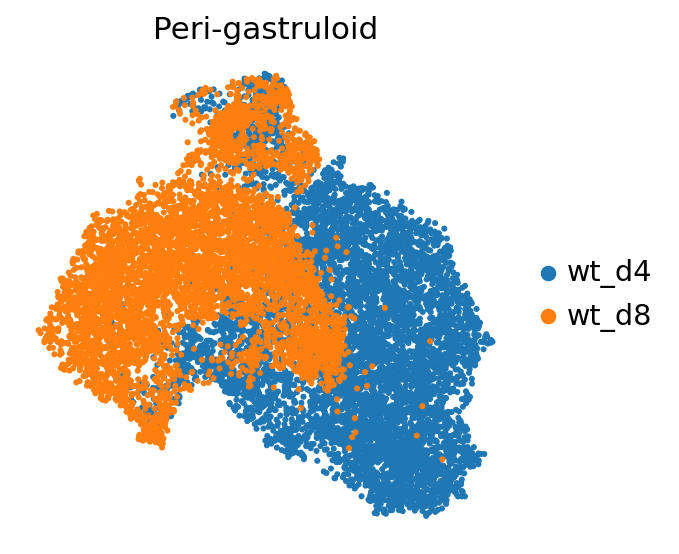

In [122]:
sc.pl.umap(adata, color=['sample'], title='Peri-gastruloid', 
          frameon=False, size=30)

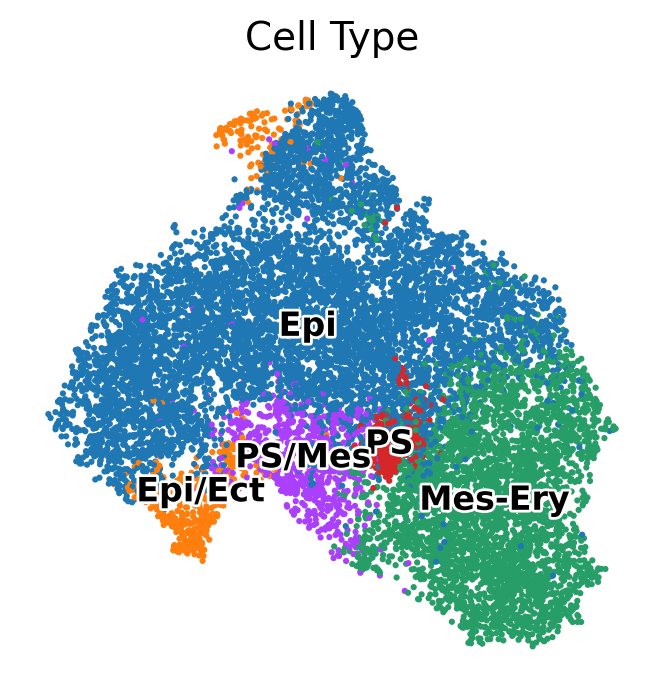

In [32]:
sc.pl.umap(adata_wt, color=['CellType_man'], frameon=False, legend_loc='on data', 
           legend_fontsize=12, legend_fontoutline=2, title='Cell Type', 
           size=20)

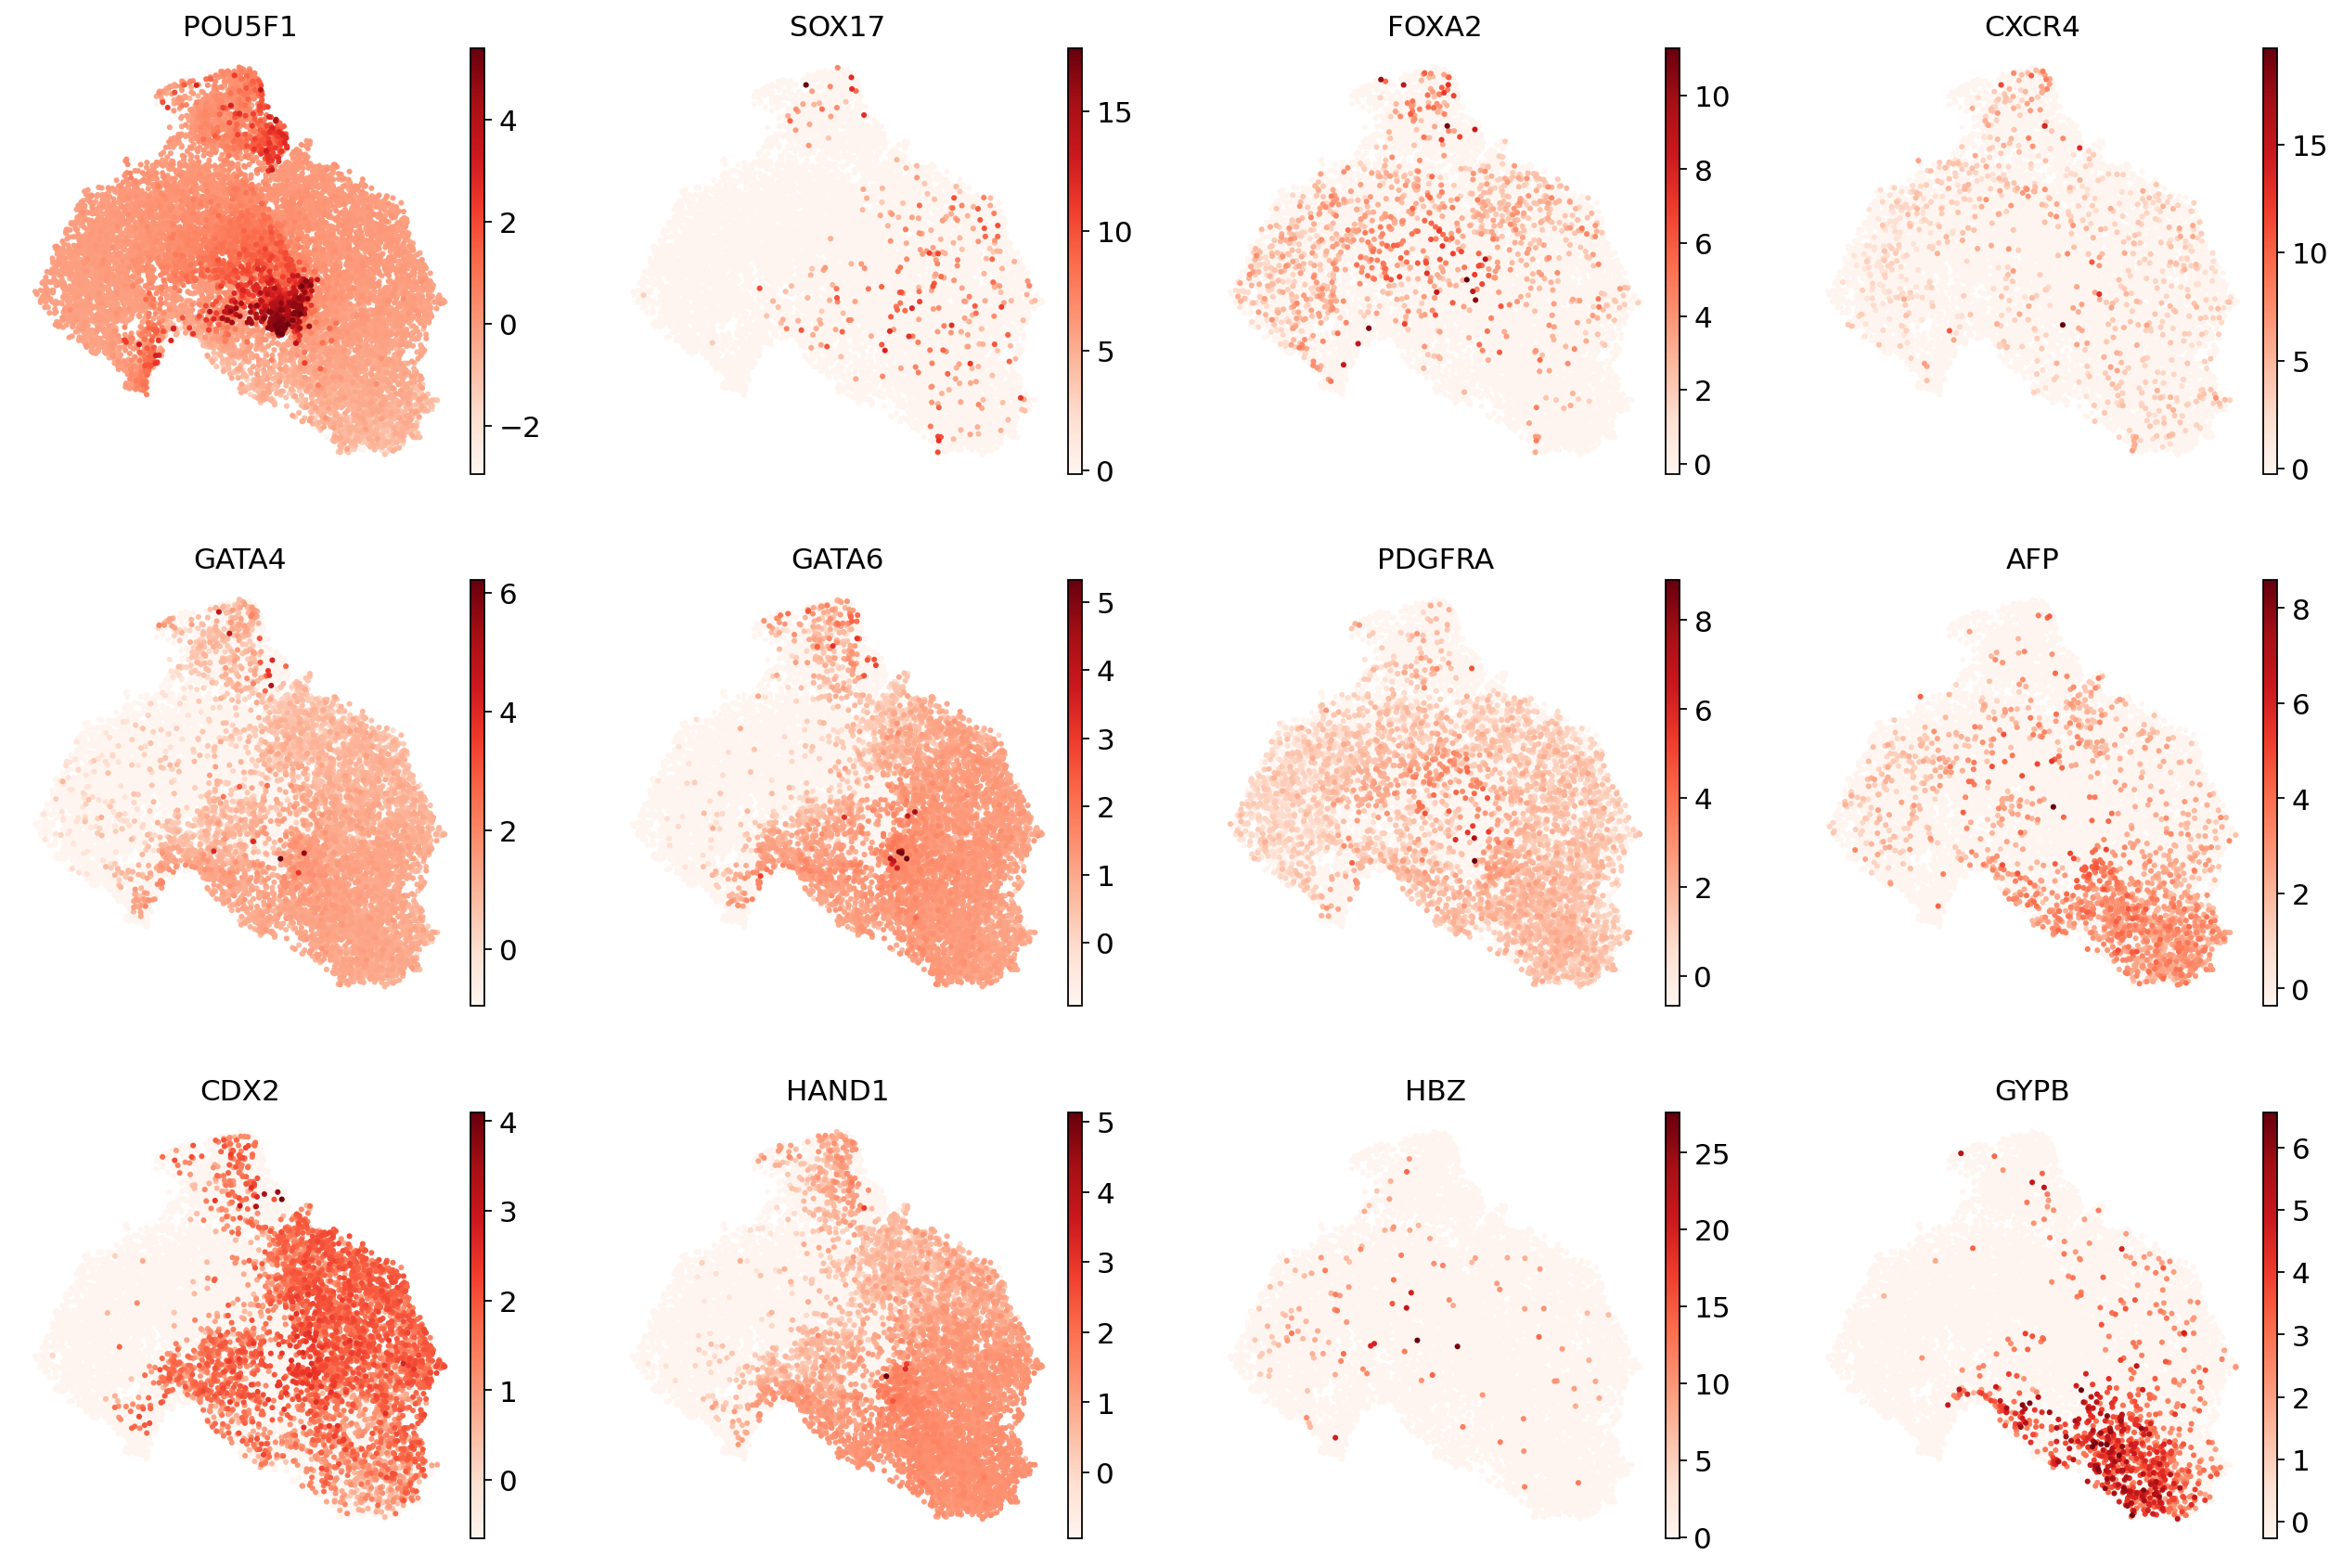

In [111]:
sc.pl.umap(adata, color=['POU5F1', 'SOX17', 'FOXA2', 'CXCR4', 
     'GATA4', 'GATA6', 'PDGFRA', 
     'AFP', 'CDX2', 'HAND1',
     'HBZ', 'GYPB'], size=30, frameon=False)